In [2]:
# Celda 1 — Verificar GPU e instalar dependencias
import torch
print(f"GPU disponible: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'ninguna'}")

!pip install roboflow pillow matplotlib seaborn pyyaml -q
print("✅ Dependencias instaladas")

GPU disponible: True
GPU: Tesla T4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 139.3 MB/s eta 0:00:00
✅ Dependencias instaladas


In [3]:
# Celda 2 — Conectar con Roboflow y descargar dataset
from roboflow import Roboflow

ROBOFLOW_API_KEY = "tlCulKdO0462FO1mTlrw"  # ← pon tu key aquí
DATASET_PATH = "/content/dataset"

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("dimitar-dimitrov-qnnci").project("logo-detection-clean")
version = project.version(3)
dataset = version.download("yolov8", location=DATASET_PATH)

print(f"✅ Dataset descargado en: {DATASET_PATH}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/dataset in yolov8:: 100%|██████████| 34400/34400 [00:04<00:00, 6928.74it/s]


✅ Dataset descargado en: /content/dataset


In [4]:
# Celda 3 — Cargar configuración y ver clases
import yaml
import os

with open(f"{DATASET_PATH}/data.yaml") as f:
    config = yaml.safe_load(f)

CLASES = config["names"]
NUM_CLASES = len(CLASES)

print(f"Número de clases: {NUM_CLASES}")
print(f"Clases: {CLASES}")
print()

# Conteo por split
splits = ["train", "valid", "test"]
total = 0
for split in splits:
    img_path = f"{DATASET_PATH}/{split}/images"
    lbl_path = f"{DATASET_PATH}/{split}/labels"
    if not os.path.exists(img_path):
        print(f"⚠️ {split}: no encontrado")
        continue
    imgs = len(os.listdir(img_path))
    lbls = len(os.listdir(lbl_path))
    estado = "✅" if imgs == lbls else "❌ no coinciden"
    print(f"{split}: {imgs} imágenes, {lbls} etiquetas {estado}")
    total += imgs

print(f"\nTotal imágenes: {total}")

Número de clases: 15
Clases: ['Adidas', 'Apple Inc-', 'Chanel', 'Coca-Cola', 'Emirates', 'Hard Rock Cafe', 'Mercedes-Benz', 'NFL', 'Nike', 'Pepsi', 'Puma', 'Starbucks', 'The North Face', 'Toyota', 'Under Armour']

train: 14721 imágenes, 14721 etiquetas ✅
valid: 1481 imágenes, 1481 etiquetas ✅
test: 992 imágenes, 992 etiquetas ✅

Total imágenes: 17194


Imágenes sin etiqueta: 0
Etiquetas sin imagen:  0

Detecciones por clase:
  Adidas              :  1945 ███████████████████
  Nike                :  1925 ███████████████████
  Coca-Cola           :  1654 ████████████████
  NFL                 :  1609 ████████████████
  Starbucks           :  1595 ███████████████
  Puma                :  1527 ███████████████
  Emirates            :  1339 █████████████
  The North Face      :  1319 █████████████
  Under Armour        :  1311 █████████████
  Mercedes-Benz       :  1301 █████████████
  Chanel              :  1258 ████████████
  Toyota              :  1211 ████████████
  Apple Inc-          :  1159 ███████████
  Hard Rock Cafe      :  1143 ███████████
  Pepsi               :  1054 ██████████




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



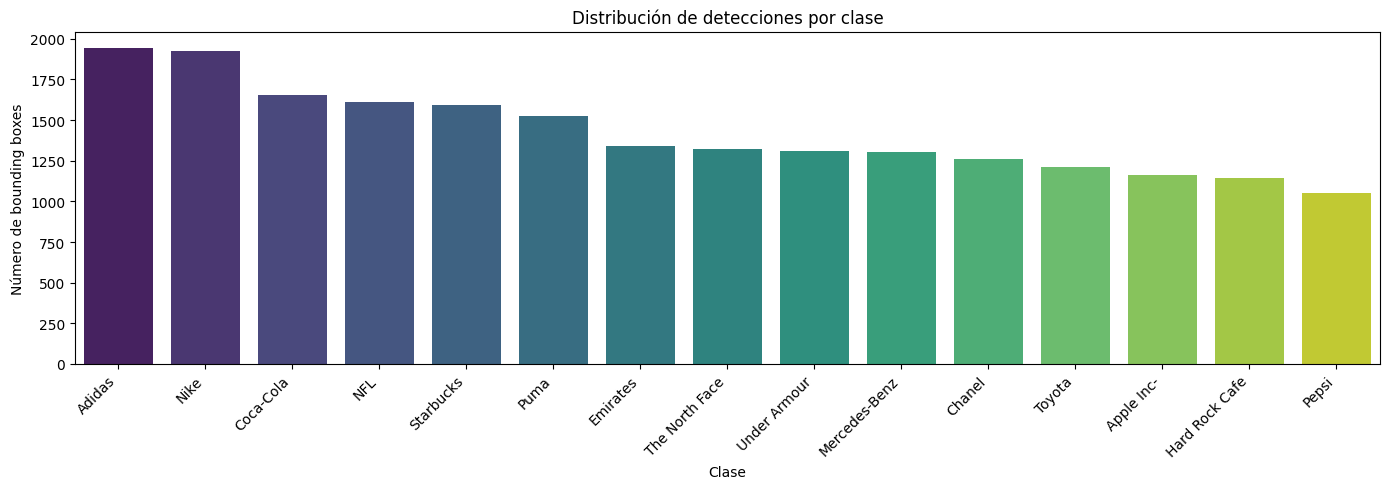

In [5]:
# Celda 4 — Distribución de clases
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

conteo_clases = defaultdict(int)
imagenes_sin_etiqueta = []
etiquetas_sin_imagen = []

for split in splits:
    img_path = f"{DATASET_PATH}/{split}/images"
    lbl_path = f"{DATASET_PATH}/{split}/labels"

    if not os.path.exists(lbl_path):
        continue

    imgs_nombres = {os.path.splitext(f)[0] for f in os.listdir(img_path)}
    lbls_nombres = {os.path.splitext(f)[0] for f in os.listdir(lbl_path)}

    imagenes_sin_etiqueta += [f"{split}/{n}" for n in imgs_nombres - lbls_nombres]
    etiquetas_sin_imagen  += [f"{split}/{n}" for n in lbls_nombres - imgs_nombres]

    for lbl_file in os.listdir(lbl_path):
        with open(f"{lbl_path}/{lbl_file}") as f:
            for linea in f:
                partes = linea.strip().split()
                if partes:
                    clase_id = int(partes[0])
                    conteo_clases[CLASES[clase_id]] += 1

print(f"Imágenes sin etiqueta: {len(imagenes_sin_etiqueta)}")
print(f"Etiquetas sin imagen:  {len(etiquetas_sin_imagen)}")
print()

clases_ord = sorted(conteo_clases.items(), key=lambda x: x[1], reverse=True)
print("Detecciones por clase:")
for nombre, count in clases_ord:
    barra = "█" * (count // 100)
    print(f"  {nombre:20s}: {count:5d} {barra}")

# Gráfico
nombres = [c[0] for c in clases_ord]
counts  = [c[1] for c in clases_ord]

plt.figure(figsize=(14, 5))
sns.barplot(x=nombres, y=counts, palette="viridis")
plt.title("Distribución de detecciones por clase")
plt.xlabel("Clase")
plt.ylabel("Número de bounding boxes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
# Celda 5 — Detectar imágenes corruptas
from PIL import Image

corruptas = []

for split in splits:
    img_path = f"{DATASET_PATH}/{split}/images"
    if not os.path.exists(img_path):
        continue
    for archivo in os.listdir(img_path):
        ruta = f"{img_path}/{archivo}"
        try:
            img = Image.open(ruta)
            img.verify()
        except Exception as e:
            corruptas.append((ruta, str(e)))

if corruptas:
    print(f"❌ {len(corruptas)} imágenes corruptas:")
    for ruta, error in corruptas:
        print(f"   {ruta}: {error}")
else:
    print("✅ No hay imágenes corruptas")

✅ No hay imágenes corruptas


Total bounding boxes: 21350
Ancho medio: 0.148 (95px)
Alto medio:  0.123  (79px)
Area media:  0.0263
Cajas pequeñas menor 2%: 14947
Cajas grandes mayor 50%: 49


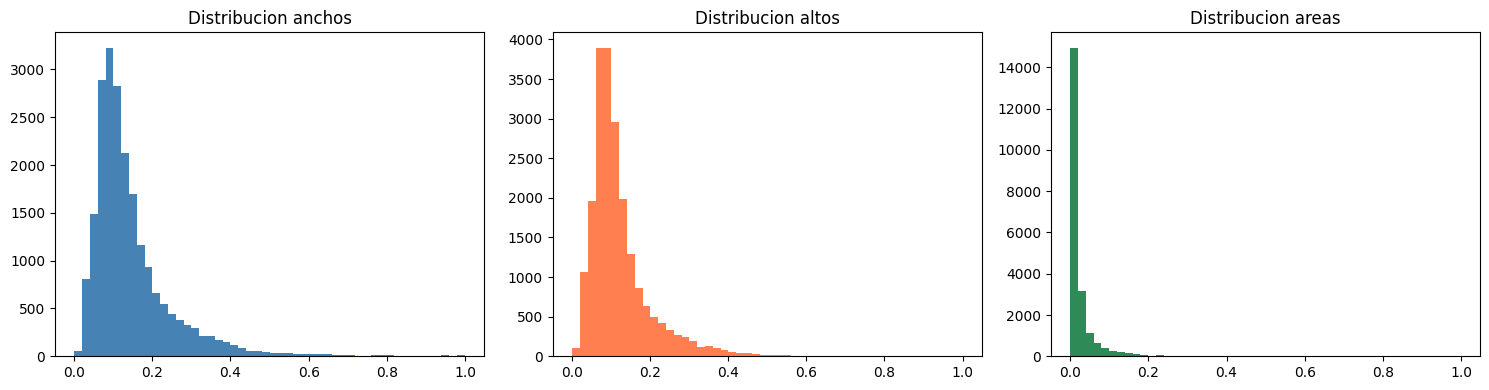

In [7]:
# Celda 6 — Análisis de bounding boxes
import numpy as np
import matplotlib.pyplot as plt

anchos, altos, areas = [], [], []

for split in splits:
    lbl_path = f"{DATASET_PATH}/{split}/labels"
    if not os.path.exists(lbl_path):
        continue
    for lbl_file in os.listdir(lbl_path):
        with open(f"{lbl_path}/{lbl_file}") as f:
            for linea in f:
                partes = linea.strip().split()
                if len(partes) == 5:
                    _, cx, cy, w, h = map(float, partes)
                    anchos.append(w)
                    altos.append(h)
                    areas.append(w * h)

print(f"Total bounding boxes: {len(areas)}")
print(f"Ancho medio: {np.mean(anchos):.3f} ({np.mean(anchos)*640:.0f}px)")
print(f"Alto medio:  {np.mean(altos):.3f}  ({np.mean(altos)*640:.0f}px)")
print(f"Area media:  {np.mean(areas):.4f}")
print(f"Cajas pequeñas menor 2%: {sum(1 for a in areas if a < 0.02)}")
print(f"Cajas grandes mayor 50%: {sum(1 for a in areas if a > 0.50)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(anchos, bins=50, color="steelblue")
axes[0].set_title("Distribucion anchos")
axes[1].hist(altos, bins=50, color="coral")
axes[1].set_title("Distribucion altos")
axes[2].hist(areas, bins=50, color="seagreen")
axes[2].set_title("Distribucion areas")
plt.tight_layout()
plt.show()

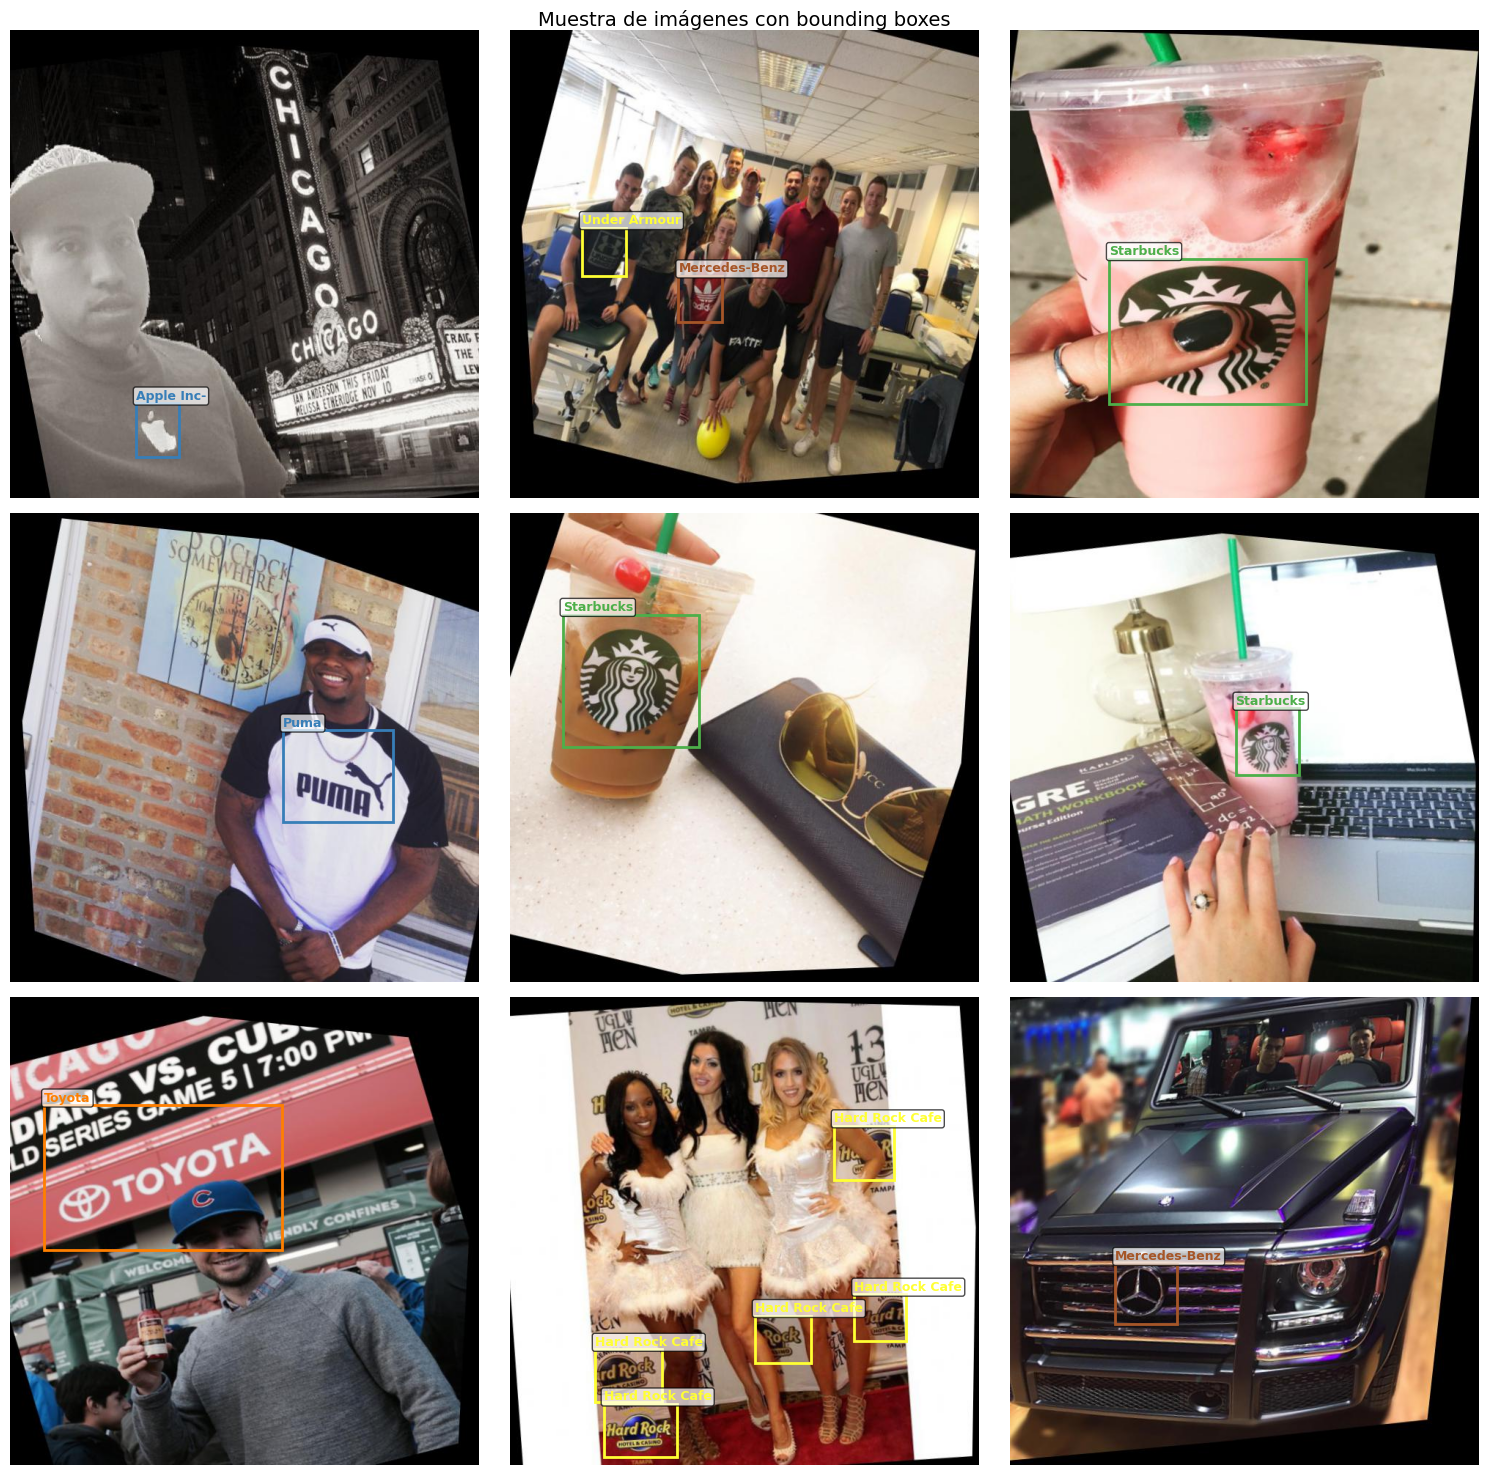

In [8]:
# Celda 7 — Visualizar muestra con bounding boxes
import random
import matplotlib.patches as patches
from PIL import Image

def dibujar_cajas(img_path, lbl_path, clase_nombres):
    archivos = [f for f in os.listdir(img_path) if f.endswith((".jpg", ".png"))]
    muestra = random.sample(archivos, min(9, len(archivos)))

    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()
    colores = plt.cm.Set1.colors

    for i, archivo in enumerate(muestra):
        img = Image.open(f"{img_path}/{archivo}").convert("RGB")
        w_img, h_img = img.size
        ax = axes[i]
        ax.imshow(img)
        ax.axis("off")

        lbl_file = f"{lbl_path}/{os.path.splitext(archivo)[0]}.txt"
        if os.path.exists(lbl_file):
            with open(lbl_file) as f:
                for linea in f:
                    partes = linea.strip().split()
                    if len(partes) == 5:
                        clase_id = int(partes[0])
                        cx, cy, bw, bh = map(float, partes[1:])
                        x = (cx - bw/2) * w_img
                        y = (cy - bh/2) * h_img
                        rect = patches.Rectangle(
                            (x, y), bw*w_img, bh*h_img,
                            linewidth=2,
                            edgecolor=colores[clase_id % len(colores)],
                            facecolor="none"
                        )
                        ax.add_patch(rect)
                        ax.text(
                            x, y - 5,
                            clase_nombres[clase_id],
                            color=colores[clase_id % len(colores)],
                            fontsize=9, fontweight="bold",
                            bbox=dict(boxstyle="round,pad=0.2",
                                     facecolor="white", alpha=0.7)
                        )

    plt.suptitle("Muestra de imágenes con bounding boxes", fontsize=14)
    plt.tight_layout()
    plt.show()

dibujar_cajas(
    f"{DATASET_PATH}/train/images",
    f"{DATASET_PATH}/train/labels",
    CLASES
)

In [9]:
# Celda 8 — Verificar duplicados por nombre de archivo
from collections import Counter

todos_archivos = []

for split in splits:
    img_path = f"{DATASET_PATH}/{split}/images"
    if not os.path.exists(img_path):
        continue
    for archivo in os.listdir(img_path):
        todos_archivos.append(archivo)

conteo = Counter(todos_archivos)
duplicados = {k: v for k, v in conteo.items() if v > 1}

if duplicados:
    print(f"❌ {len(duplicados)} archivos duplicados encontrados:")
    for nombre, count in duplicados.items():
        print(f"   {nombre}: aparece {count} veces")
else:
    print(f"✅ No hay duplicados — {len(todos_archivos)} archivos únicos")

✅ No hay duplicados — 17194 archivos únicos


In [11]:
# Celda 8 — Resumen final EDA (actualizado)
print("=" * 50)
print("RESUMEN EDA - Logo Detection Clean v3")
print("=" * 50)
print(f"Total imágenes:          {total}")
print(f"Total bounding boxes:    {len(areas)}")
print(f"Clases:                  {NUM_CLASES}")
print(f"Imágenes corruptas:      0")
print(f"Desaparejados:           0")
print(f"Duplicados:              0 ✅")
print(f"Cajas pequeñas (<2%):    {sum(1 for a in areas if a < 0.02)}")
print(f"Cajas grandes (>50%):    {sum(1 for a in areas if a > 0.50)}")
print()
print("Nuestras 3 marcas:")
for nombre, count in clases_ord:
    if nombre in ["Nike", "Adidas", "Coca-Cola"]:
        print(f"  {nombre:15s}: {count} detecciones ✅")
print()
ratio = clases_ord[0][1] / clases_ord[-1][1]
print(f"Ratio desbalance:        {ratio:.1f}x ✅ aceptable")
print()
print("Conclusión: dataset listo para entrenamiento")
print("Recomendación: imgsz=640, vigilar objetos pequeños")
print("=" * 50)

RESUMEN EDA - Logo Detection Clean v3
Total imágenes:          17194
Total bounding boxes:    21350
Clases:                  15
Imágenes corruptas:      0
Desaparejados:           0
Duplicados:              0 ✅
Cajas pequeñas (<2%):    14947
Cajas grandes (>50%):    49

Nuestras 3 marcas:
  Adidas         : 1945 detecciones ✅
  Nike           : 1925 detecciones ✅
  Coca-Cola      : 1654 detecciones ✅

Ratio desbalance:        1.8x ✅ aceptable

Conclusión: dataset listo para entrenamiento
Recomendación: imgsz=640, vigilar objetos pequeños
